# Nama    : Fawwaz Rif'at Revista
# NIM     : 25/565782/PPA/07130
# Task 1 KKPM

In [1]:
# Import libraries
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
# Load data
name = "heart_failure_clinical_records_dataset.csv"
data = pd.read_csv(name)
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Menghitung jumlah masing-masing label target
print(data['DEATH_EVENT'].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


/tmp/ipython-input-51825/2169375395.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEATH_EVENT', data=data, palette='viridis')


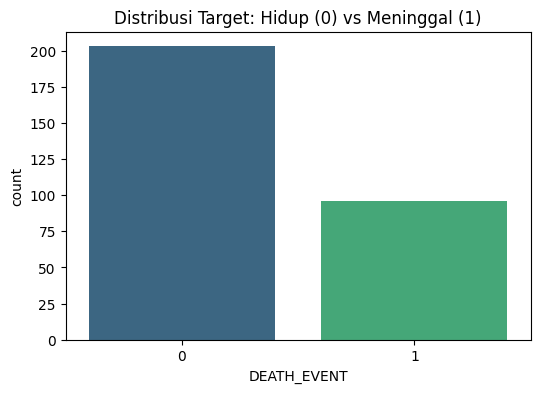

In [5]:
# Cek jumlah asli
print(data['DEATH_EVENT'].value_counts())

# Visualisasi
plt.figure(figsize=(6, 4))
sns.countplot(x='DEATH_EVENT', data=data, palette='viridis')
plt.title('Distribusi Target: Hidup (0) vs Meninggal (1)')
plt.show()

In [6]:
# Persiapan Data
df = data
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Model MLP (TANPA SCALING) dengan lbfgs
print("Model TANPA scaling")
mlp_tanpa_scaling = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50), random_state=1)

# Melatih dan uji Model
mlp_tanpa_scaling.fit(X_train, y_train)

# Prediksi untuk Train dan Test
y_pred_train = mlp_tanpa_scaling.predict(X_train)    # Prediksi data train
y_pred_raw = mlp_tanpa_scaling.predict(X_test)    # Prediksi data test

# Evaluasi hasil (Akurasi)
akurasi_train = accuracy_score(y_train, y_pred_train)
akurasi_raw = accuracy_score(y_test, y_pred_raw)

# Evaluasi hasil (Precision)
presisi_train = precision_score(y_train, y_pred_train, zero_division=0)
presisi_raw = precision_score(y_test, y_pred_raw, zero_division=0)

# Evaluasi hasil (Recall)
rekal_train = recall_score(y_train, y_pred_train, zero_division=0)
rekal_raw = recall_score(y_test, y_pred_raw, zero_division=0)

# Menampilkan semua hasil evaluasi
print(f"Akurasi MLP Train                   : {akurasi_train * 100:.2f}%")
print(f"Akurasi MLP Tanpa Scaling Test      : {akurasi_raw * 100:.2f}%")
print(f"Precision Train                     : {presisi_train * 100:.2f}%")
print(f"Precision Test                      : {presisi_raw * 100:.2f}%")
print(f"Recall Train                        : {rekal_train * 100:.2f}%")
print(f"Recall Test                         : {rekal_raw * 100:.2f}%")

Model TANPA scaling
Akurasi MLP Train                   : 70.29%
Akurasi MLP Tanpa Scaling Test      : 58.33%
Precision Train                     : 0.00%
Precision Test                      : 0.00%
Recall Train                        : 0.00%
Recall Test                         : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [7]:
# Persiapan Data
df = data
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Model MLP (TANPA SCALING) dengan lbfgs
print("Model TANPA scaling")
mlp_tanpa_scaling = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50), random_state=1, max_iter=100000)

# Melatih dan uji Model
mlp_tanpa_scaling.fit(X_train, y_train)

# Prediksi untuk Train dan Test
y_pred_train = mlp_tanpa_scaling.predict(X_train)    # Prediksi data train
y_pred_raw = mlp_tanpa_scaling.predict(X_test)    # Prediksi data test

# Evaluasi hasil (Akurasi)
akurasi_train = accuracy_score(y_train, y_pred_train)
akurasi_raw = accuracy_score(y_test, y_pred_raw)

# Evaluasi hasil (Precision)
presisi_train = precision_score(y_train, y_pred_train, zero_division=0)
presisi_raw = precision_score(y_test, y_pred_raw, zero_division=0)

# Evaluasi hasil (Recall)
rekal_train = recall_score(y_train, y_pred_train, zero_division=0)
rekal_raw = recall_score(y_test, y_pred_raw, zero_division=0)

# Menampilkan semua hasil evaluasi
print(f"Akurasi MLP Train                   : {akurasi_train * 100:.2f}%")
print(f"Akurasi MLP Tanpa Scaling Test      : {akurasi_raw * 100:.2f}%")
print(f"Precision Train                     : {presisi_train * 100:.2f}%")
print(f"Precision Test                      : {presisi_raw * 100:.2f}%")
print(f"Recall Train                        : {rekal_train * 100:.2f}%")
print(f"Recall Test                         : {rekal_raw * 100:.2f}%")

Model TANPA scaling
Akurasi MLP Train                   : 70.29%
Akurasi MLP Tanpa Scaling Test      : 58.33%
Precision Train                     : 0.00%
Precision Test                      : 0.00%
Recall Train                        : 0.00%
Recall Test                         : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [8]:
# Persiapan Data
df = data
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Model MLP (TANPA SCALING) dengan lbfgs
print("Model TANPA scaling")
mlp_tanpa_scaling = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50), random_state=1, max_iter=10000)

# Melatih dan uji Model
mlp_tanpa_scaling.fit(X_train, y_train)

# Prediksi untuk Train dan Test
y_pred_train = mlp_tanpa_scaling.predict(X_train)    # Prediksi data train
y_pred_raw = mlp_tanpa_scaling.predict(X_test)    # Prediksi data test

# Evaluasi hasil (Akurasi)
akurasi_train = accuracy_score(y_train, y_pred_train)
akurasi_raw = accuracy_score(y_test, y_pred_raw)

# Evaluasi hasil (Precision)
presisi_train = precision_score(y_train, y_pred_train, zero_division=0)
presisi_raw = precision_score(y_test, y_pred_raw, zero_division=0)

# Evaluasi hasil (Recall)
rekal_train = recall_score(y_train, y_pred_train, zero_division=0)
rekal_raw = recall_score(y_test, y_pred_raw, zero_division=0)

# Menampilkan semua hasil evaluasi
print(f"Akurasi MLP Train                   : {akurasi_train * 100:.2f}%")
print(f"Akurasi MLP Tanpa Scaling Test      : {akurasi_raw * 100:.2f}%")
print(f"Precision Train                     : {presisi_train * 100:.2f}%")
print(f"Precision Test                      : {presisi_raw * 100:.2f}%")
print(f"Recall Train                        : {rekal_train * 100:.2f}%")
print(f"Recall Test                         : {rekal_raw * 100:.2f}%")

Model TANPA scaling
Akurasi MLP Train                   : 70.29%
Akurasi MLP Tanpa Scaling Test      : 58.33%
Precision Train                     : 0.00%
Precision Test                      : 0.00%
Recall Train                        : 0.00%
Recall Test                         : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [9]:
# Persiapan Data
df = data
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling dengan Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membangun Model MLP (DENGAN SCALING) dengan lbfgs
print("Model DENGAN scaling")
mlp_dengan_scaling = MLPClassifier(solver='lbfgs', hidden_layer_sizes=(100, 50), random_state=1)

# Melatih Model
mlp_dengan_scaling.fit(X_train_scaled, y_train)

# Prediksi untuk Data Train dan Data Test
y_pred_train_scaled = mlp_dengan_scaling.predict(X_train_scaled) # Prediksi data latih
y_pred_test_scaled = mlp_dengan_scaling.predict(X_test_scaled)   # Prediksi data uji

# Evaluasi hasil (Akurasi)
akurasi_train = accuracy_score(y_train, y_pred_train_scaled)
akurasi_test = accuracy_score(y_test, y_pred_test_scaled)

# Evaluasi hasil (Precision)
presisi_train = precision_score(y_train, y_pred_train_scaled, zero_division=0)
presisi_test = precision_score(y_test, y_pred_test_scaled, zero_division=0)

# Evaluasi hasil (Recall)
rekal_train = recall_score(y_train, y_pred_train_scaled, zero_division=0)
rekal_test = recall_score(y_test, y_pred_test_scaled, zero_division=0)



# Menampilkan semua hasil evaluasi
print("HASIL EVALUASI DENGAN SCALING")
print(f"Akurasi Train   : {akurasi_train * 100:.2f}%")
print(f"Akurasi Test    : {akurasi_test * 100:.2f}%")
print(f"Precision Train : {presisi_train * 100:.2f}%")
print(f"Precision Test  : {presisi_test * 100:.2f}%")
print(f"Recall Train    : {rekal_train * 100:.2f}%")
print(f"Recall Test     : {rekal_test * 100:.2f}%")

Model DENGAN scaling
HASIL EVALUASI DENGAN SCALING
Akurasi Train   : 100.00%
Akurasi Test    : 66.67%
Precision Train : 100.00%
Precision Test  : 61.90%
Recall Train    : 100.00%
Recall Test     : 52.00%


In [10]:
# Training dan uji dengan berbagai skenario
# Ignore warning karena model tanpa scaling akan memunculkan banyak warning gagal konvergen.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Persiapan Data
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling dengan Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Persiapan variabel eksperimen untuk berbagai skenario
solvers = ['adam', 'lbfgs', 'sgd']
iterasi_list = [200, 500, 750, 1000]

# List kosong untuk menyimpan skor setiap uji coba
hasil_eksperimen = []

# Looping eksperimen berbagai skenario
for solver_choice in solvers:
    for iterasi in iterasi_list:

        # SKENARIO 1 : TANPA SCALING
        mlp_raw = MLPClassifier(solver=solver_choice,
                                hidden_layer_sizes=(20, 10), random_state=1, max_iter=iterasi, batch_size=20, alpha=1e-4, activation='relu')
        mlp_raw.fit(X_train, y_train)

        # Prediksi Train & Test
        pred_train_raw = mlp_raw.predict(X_train)
        pred_test_raw = mlp_raw.predict(X_test)

        # Metrik Tanpa Scaling
        acc_tr_raw = accuracy_score(y_train, pred_train_raw)
        acc_ts_raw = accuracy_score(y_test, pred_test_raw)
        prec_tr_raw = precision_score(y_train, pred_train_raw, zero_division=0)
        prec_ts_raw = precision_score(y_test, pred_test_raw, zero_division=0)
        rec_tr_raw = recall_score(y_train, pred_train_raw, zero_division=0)
        rec_ts_raw = recall_score(y_test, pred_test_raw, zero_division=0)

        # SKENARIO 2: DENGAN SCALING
        mlp_scaled = MLPClassifier(solver=solver_choice,
                                   hidden_layer_sizes=(20, 10), random_state=1, max_iter=iterasi, batch_size=20, alpha=1e-4, activation='relu')
        mlp_scaled.fit(X_train_scaled, y_train)

        # Prediksi Train & Test
        pred_train_scaled = mlp_scaled.predict(X_train_scaled)
        pred_test_scaled = mlp_scaled.predict(X_test_scaled)

        # Metrik Dengan Scaling
        acc_tr_sc = accuracy_score(y_train, pred_train_scaled)
        acc_ts_sc = accuracy_score(y_test, pred_test_scaled)
        prec_tr_sc = precision_score(y_train, pred_train_scaled, zero_division=0)
        prec_ts_sc = precision_score(y_test, pred_test_scaled, zero_division=0)
        rec_tr_sc = recall_score(y_train, pred_train_scaled, zero_division=0)
        rec_ts_sc = recall_score(y_test, pred_test_scaled, zero_division=0)

        # SIMPAN HASIL KE DALAM LIST
        hasil_eksperimen.append({
            'Solver': solver_choice.upper(),
            'Iter': iterasi,

            # Kolom Raw (Tanpa Scaling)
            'Tr_Acc(Raw)': f"{acc_tr_raw * 100:.1f}%",
            'Ts_Acc(Raw)': f"{acc_ts_raw * 100:.1f}%",
            'Tr_Prc(Raw)': f"{prec_tr_raw * 100:.1f}%",
            'Ts_Prc(Raw)': f"{prec_ts_raw * 100:.1f}%",
            'Tr_Rec(Raw)': f"{rec_tr_raw * 100:.1f}%",
            'Ts_Rec(Raw)': f"{rec_ts_raw * 100:.1f}%",

            # Kolom Scaled (Dengan Scaling)
            'Tr_Acc(Scale)': f"{acc_tr_sc * 100:.1f}%",
            'Ts_Acc(Scale)': f"{acc_ts_sc * 100:.1f}%",
            'Tr_Prc(Scale)': f"{prec_tr_sc * 100:.1f}%",
            'Ts_Prc(Scale)': f"{prec_ts_sc * 100:.1f}%",
            'Tr_Rec(Scale)': f"{rec_tr_sc * 100:.1f}%",
            'Ts_Rec(Scale)': f"{rec_ts_sc * 100:.1f}%"
        })

# Menampilkan Hasil dalam Bentuk Tabel
df_hasil = pd.DataFrame(hasil_eksperimen)

print("TABEL HASIL EKSPERIMEN MLP (ARSITEKTUR 20, 10)\n")
# to_string() digunakan agar tabel Pandas tampil rapi di console
print(df_hasil.to_string(index=False))

TABEL HASIL EKSPERIMEN MLP (ARSITEKTUR 20, 10)

Solver  Iter Tr_Acc(Raw) Ts_Acc(Raw) Tr_Prc(Raw) Ts_Prc(Raw) Tr_Rec(Raw) Ts_Rec(Raw) Tr_Acc(Scale) Ts_Acc(Scale) Tr_Prc(Scale) Ts_Prc(Scale) Tr_Rec(Scale) Ts_Rec(Scale)
  ADAM   200       69.0%       73.3%       51.3%       56.0%       79.2%       73.7%        100.0%         66.7%        100.0%         46.7%        100.0%         36.8%
  ADAM   500       69.0%       73.3%       51.3%       56.0%       79.2%       73.7%        100.0%         71.7%        100.0%         57.1%        100.0%         42.1%
  ADAM   750       69.0%       73.3%       51.3%       56.0%       79.2%       73.7%        100.0%         71.7%        100.0%         57.1%        100.0%         42.1%
  ADAM  1000       69.0%       73.3%       51.3%       56.0%       79.2%       73.7%        100.0%         71.7%        100.0%         57.1%        100.0%         42.1%
 LBFGS   200       32.2%       31.7%       32.2%       31.7%      100.0%      100.0%        100.0%         

In [11]:
# Training dan uji dengan berbagai skenario
# Ignore warning karena model tanpa scaling akan memunculkan banyak warning gagal konvergen.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Persiapan Data
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

# Memisahkan Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling dengan Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Persiapan variabel eksperimen untuk berbagai skenario
solvers = ['adam', 'lbfgs', 'sgd']
iterasi_list = [200, 500, 750, 1000]

# List kosong untuk menyimpan skor setiap uji coba
hasil_eksperimen = []

# Looping eksperimen berbagai skenario
for solver_choice in solvers:
    for iterasi in iterasi_list:

        # SKENARIO 1 : TANPA SCALING
        mlp_raw = MLPClassifier(solver=solver_choice,
                                hidden_layer_sizes=(20, 10), random_state=1, max_iter=iterasi, batch_size=32, alpha=1e-4)
        mlp_raw.fit(X_train, y_train)

        # Prediksi Train & Test
        pred_train_raw = mlp_raw.predict(X_train)
        pred_test_raw = mlp_raw.predict(X_test)

        # Metrik Tanpa Scaling
        acc_tr_raw = accuracy_score(y_train, pred_train_raw)
        acc_ts_raw = accuracy_score(y_test, pred_test_raw)
        prec_tr_raw = precision_score(y_train, pred_train_raw, zero_division=0)
        prec_ts_raw = precision_score(y_test, pred_test_raw, zero_division=0)
        rec_tr_raw = recall_score(y_train, pred_train_raw, zero_division=0)
        rec_ts_raw = recall_score(y_test, pred_test_raw, zero_division=0)

        # SKENARIO 2: DENGAN SCALING
        mlp_scaled = MLPClassifier(solver=solver_choice,
                                   hidden_layer_sizes=(20, 10), random_state=1, max_iter=iterasi, batch_size=32, alpha=1e-4)
        mlp_scaled.fit(X_train_scaled, y_train)

        # Prediksi Train & Test
        pred_train_scaled = mlp_scaled.predict(X_train_scaled)
        pred_test_scaled = mlp_scaled.predict(X_test_scaled)

        # Metrik Dengan Scaling
        acc_tr_sc = accuracy_score(y_train, pred_train_scaled)
        acc_ts_sc = accuracy_score(y_test, pred_test_scaled)
        prec_tr_sc = precision_score(y_train, pred_train_scaled, zero_division=0)
        prec_ts_sc = precision_score(y_test, pred_test_scaled, zero_division=0)
        rec_tr_sc = recall_score(y_train, pred_train_scaled, zero_division=0)
        rec_ts_sc = recall_score(y_test, pred_test_scaled, zero_division=0)

        # SIMPAN HASIL KE DALAM LIST
        hasil_eksperimen.append({
            'Solver': solver_choice.upper(),
            'Iter': iterasi,

            # Kolom Raw (Tanpa Scaling)
            'Tr_Acc(Raw)': f"{acc_tr_raw * 100:.1f}%",
            'Ts_Acc(Raw)': f"{acc_ts_raw * 100:.1f}%",
            'Tr_Prc(Raw)': f"{prec_tr_raw * 100:.1f}%",
            'Ts_Prc(Raw)': f"{prec_ts_raw * 100:.1f}%",
            'Tr_Rec(Raw)': f"{rec_tr_raw * 100:.1f}%",
            'Ts_Rec(Raw)': f"{rec_ts_raw * 100:.1f}%",

            # Kolom Scaled (Dengan Scaling)
            'Tr_Acc(Scale)': f"{acc_tr_sc * 100:.1f}%",
            'Ts_Acc(Scale)': f"{acc_ts_sc * 100:.1f}%",
            'Tr_Prc(Scale)': f"{prec_tr_sc * 100:.1f}%",
            'Ts_Prc(Scale)': f"{prec_ts_sc * 100:.1f}%",
            'Tr_Rec(Scale)': f"{rec_tr_sc * 100:.1f}%",
            'Ts_Rec(Scale)': f"{rec_ts_sc * 100:.1f}%"
        })

# Menampilkan Hasil dalam Bentuk Tabel
df_hasil = pd.DataFrame(hasil_eksperimen)

print("TABEL HASIL EKSPERIMEN MLP (ARSITEKTUR 20, 10)\n")
# to_string() digunakan agar tabel Pandas tampil rapi di console
print(df_hasil.to_string(index=False))

TABEL HASIL EKSPERIMEN MLP (ARSITEKTUR 20, 10)

Solver  Iter Tr_Acc(Raw) Ts_Acc(Raw) Tr_Prc(Raw) Ts_Prc(Raw) Tr_Rec(Raw) Ts_Rec(Raw) Tr_Acc(Scale) Ts_Acc(Scale) Tr_Prc(Scale) Ts_Prc(Scale) Tr_Rec(Scale) Ts_Rec(Scale)
  ADAM   200       67.8%       68.3%        0.0%        0.0%        0.0%        0.0%         97.9%         68.3%         97.4%         50.0%         96.1%         36.8%
  ADAM   500       67.8%       68.3%        0.0%        0.0%        0.0%        0.0%        100.0%         70.0%        100.0%         53.8%        100.0%         36.8%
  ADAM   750       67.8%       68.3%        0.0%        0.0%        0.0%        0.0%        100.0%         70.0%        100.0%         53.8%        100.0%         36.8%
  ADAM  1000       67.8%       68.3%        0.0%        0.0%        0.0%        0.0%        100.0%         70.0%        100.0%         53.8%        100.0%         36.8%
 LBFGS   200       32.2%       31.7%       32.2%       31.7%      100.0%      100.0%        100.0%         